<a href="https://colab.research.google.com/github/joyangelai/Colabs-Vol-2/blob/main/RandomForest%2C_XGboost%2C_%26_Dealing_with_Imbalance_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest

In [ ]:
#load the libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# get titanic & test csv files as a DataFrame
train = pd.read_csv("train.csv")
#
#check shape
print(f'The dataset shape is: {train.shape}', '\n********')
#check the head
train.head()


The dataset shape is: (891, 12) 
********


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#check datatypes
train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
#drop passangeid, cabin, name and ticket columns
train = train.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1)

'''
#You can also use pop method to drop the columns
train.pop("Cabin")
train.pop("Name")
train.pop("Ticket")
'''

'\n#You can also use pop method to drop the columns\ntrain.pop("Cabin")\ntrain.pop("Name")\ntrain.pop("Ticket")\n'

In [ ]:
#checking the null values
train.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
#Checking for missing data
NAs = pd.concat([train.isnull().sum()], axis=1, keys=["Train"])
NAs[NAs.sum(axis=1) > 0]

,Train
Age,177
Embarked,2


In [ ]:
# Filling missing Age values with mean
train["Age"] = train["Age"].fillna(train["Age"].mean())

# Filling missing Embarked values with most common value
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

#change the pclass from int to string
train["Pclass"] = train["Pclass"].apply(str)

In [ ]:
#check the datatypes
train.dtypes

,0
Survived,int64
Pclass,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


In [ ]:
#visual the target variable
train["Survived"].value_counts()

,count
Survived,
0,549
1,342


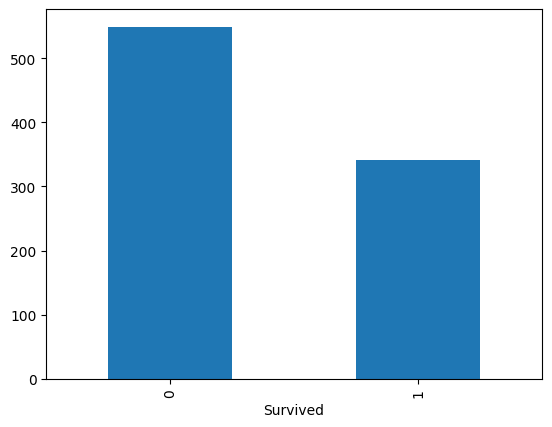

In [ ]:
train["Survived"].value_counts().plot(kind="bar");

**observation**: the data is imbalanced, we can rectify this to achive optimal model result.

## Preprocessing

In [ ]:
#get object variables
categorical_cols = train.select_dtypes(include=["object"]).columns
categorical_cols


Index(['Pclass', 'Sex', 'Embarked'], dtype='object')

In [ ]:
# Getting Dummies from all other categorical vars
categorical_cols = train.select_dtypes(include=["object"]).columns
if categorical_cols.size > 0:
    train = pd.get_dummies(train, columns=categorical_cols, drop_first=True).astype("int")
else:
    print("No categorical columns found in the DataFrame.")

In [ ]:
#check head
train.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22,1,0,7,0,1,1,0,1
1,1,38,1,0,71,0,0,0,0,0
2,1,26,0,0,7,0,1,0,0,1
3,1,35,1,0,53,0,0,0,0,1
4,0,35,0,0,8,0,1,1,0,1


In [ ]:
#save clean dataset
train.to_csv("clean_train.csv", index=False)

In [ ]:
#Divide data into train and test
x = train.drop("Survived", axis=1)
y = train["Survived"]

In [ ]:
x

In [ ]:
#split data into train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [ ]:
x_train.shape, x_test.shape

((668, 9), (223, 9))

In [ ]:
y_train.shape, y_test.shape

((668,), (223,))

In [ ]:
#call and train the model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
#Predict
y_pred = rf.predict(x_test)

In [ ]:
#creat dataframe to comapare true and predicted values
df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
df.head()

,Actual,Predicted
709,1,0
439,0,0
840,0,0
720,1,1
39,1,0


In [ ]:
#check the accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)*100

79.82062780269058

In [ ]:
#check the test score to confirm if there's overfitting of the model
rf.score(x_test, y_test)

0.7982062780269058

In [ ]:
#check roc curve score
from sklearn.metrics import roc_curve, auc
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

np.float64(0.784923696126111)

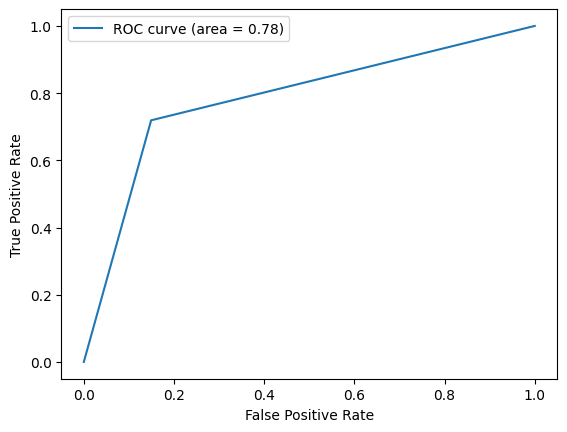

In [ ]:
#creat roc curve
import matplotlib.pyplot as plt
plt.figure()
plt.plot(false_positive_rate, true_positive_rate, label='ROC curve (area = %0.2f)' % roc_auc);
plt.xlabel('False Positive Rate');
plt.ylabel('True Positive Rate');
#add legend
plt.legend();


## Hyperparamater Tuning

In [ ]:
#1. tune using gridsearchCV
from sklearn.model_selection import GridSearchCV
# Define the parameter grid for random search
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20],
}

#get the optimal params
grid_search = GridSearchCV(estimator = rf,\
                           param_grid = param_grid,\
                           cv = 3, verbose=2, n_jobs = -1)

# Fit the grid search model
grid_search.fit(x_train, y_train)

#get the best param
grid_search.best_params_

Fitting 3 folds for each of 25 candidates, totalling 75 fits


{'max_depth': 10, 'n_estimators': 400}

In [ ]:
'''
#or you can include more params
# create randonsearch

import numpy as np
from sklearn.model_selection import RandomizedSearchCV

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 1000, num = 12)]

# Number of features to consider at every split
max_features = ['auto', 'sqrt', 'log2', None]

# Maximum depth of the tree
max_depth = [int(x) for x in np.linspace(10, 50, num = 10)]
max_depth.append(None)

# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10, 15, 100]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 5, 10]

# Create the random grid
random_grid = {'n_estimators': n_estimators,
             'max_features': max_features,
             'max_depth': max_depth,
             'min_samples_split': min_samples_split,
             'min_samples_leaf': min_samples_leaf}

# Use the random grid to search for best hyperparameters
# First create the base model to tune
rf = RandomForestClassifier()

# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=random_grid,
                               n_iter=100, cv=3, verbose=1, random_state=42, n_jobs=-1)

# Fit the random search model
rf_random.fit(x_train, y_train)
'''

In [ ]:
#creating tuned model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, max_depth=10)
rf.fit(x_train, y_train)

In [ ]:
#get prediction
y_pred = rf.predict(x_test)

In [ ]:
#check pred against actual
df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
df.head()

In [ ]:
#check accuracy
accuracy_score(y_test, y_pred)

In [ ]:
#check accuracy on test
rf.score(x_test, y_test)

In [ ]:
#2. Using random search, get the optimal number of estimators
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for random search
random_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20],
    # Add other hyperparameters you want to tune
}

#get the optimal params
rf_random = RandomizedSearchCV(estimator = rf,\
                               param_distributions = random_grid,\
                               n_iter = 100, cv = 3, verbose=2,\
                               random_state=42, n_jobs = -1)


In [ ]:
# Fit the random search model
rf_random.fit(x_train, y_train)

In [ ]:
#get the best param
rf_random.best_params_

In [ ]:
#Recreate the model with optimal params
rf = RandomForestClassifier(max_depth=5, n_estimators=500) # Use '=' to assign values to keyword arguments
rf.fit(x_train, y_train)

In [ ]:
#predict
y_pred = rf.predict(x_test)

In [ ]:
#check predicted against actaual values
df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
df.head()

In [ ]:
#check the accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

In [ ]:
#check the test score
rf.score(x_test, y_test)

In [ ]:
#check the confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

In [ ]:
#check the metrics score
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

In [ ]:
#get roc curve
from sklearn.metrics import roc_curve, auc
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

In [ ]:
#creat roc curve
import matplotlib.pyplot as plt
plt.figure()
plt.plot(false_positive_rate, true_positive_rate, label='ROC curve (area = %0.2f)' % roc_auc);
plt.xlabel('False Positive Rate');
plt.ylabel('True Positive Rate');
#add legend
plt.legend();




# XGBOOST

In [ ]:
#load the clean dataset
df = pd.read_csv("/content/clean_train.csv")
df.head()

In [ ]:
#check the target variable
print(df["Survived"].value_counts())
df["Survived"].value_counts().plot(kind="pie", \
autopct='%.2f%%',\
labels=["Not Survived", "Survived"], explode=[0.1, 0]);

Observation: there's class imbalance, we will fix this using SMOTE.

In [ ]:
#Divide the data into x and y
x = df.drop("Survived", axis=1)
y = df["Survived"]

In [ ]:
#split the data into train and test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

### Fix class imbalance using sythetic minority oversampling technique (SMOTE)

SMOTE stands for Synthetic Minority Over-sampling Technique. It's a technique used in machine learning to address datasets that are imbalanced.

An imbalanced dataset means there's a significant difference in the number of examples between different classes. For instance, imagine a dataset for fraud detection, where fraudulent transactions are rare compared to normal ones. This imbalance can cause problems when training a machine learning model.

SMOTE tackles this by creating synthetic data points for the minority class. It analyzes existing minority data and generates new ones that are similar to them. This helps to balance out the dataset and improve the model's performance on the minority class.

Here's a breakdown of how SMOTE works:

1. Identify the imbalance: First, you need to recognize that your data has a minority class.
2. Focus on the minority: SMOTE specifically creates new data points for the minority class, not the majority class.
3. Create synthetic samples: It analyzes existing minority data points and generates new ones similar to them. SMOTE does this by finding similar data points (nearest neighbors) and creating new data points along the line between them in the feature space.

SMOTE is a valuable tool for machine learning when dealing with imbalanced datasets, but it's not without limitations. It's important to be aware of these limitations and choose the right technique for your specific situation.

In [ ]:
#import SMOTE
from imblearn.over_sampling import SMOTE

#create the smote object
sm = SMOTE(sampling_strategy='auto', random_state=42)

X_train_resampled, y_train_resampled = sm.fit_resample(x_train, y_train)

#check shape
print(f'After OverSampling, the shape of train_X: {X_train_resampled.shape}')
print(f'After OverSampling, the shape of train_y: {y_train_resampled.shape}','\n')

#check the labels
print('****'*15)
print(f'After OverSampling, counts of label "1": {sum(y_train_resampled == 1)}')
print(f'After OverSampling, counts of label "0": {sum(y_train_resampled == 0)}')



In [ ]:
#call  xgboost classifier
from xgboost import XGBClassifier

#Create an object
xgb = XGBClassifier()

#Train the model
xgb.fit(X_train_resampled, y_train_resampled)

In [ ]:
#predict
y_pred = xgb.predict(x_test)

#create adata fame for actaual vs predicted values
df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
df.head()

In [ ]:
#check the accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

In [ ]:
#test score
xgb.score(x_test, y_test)

In [ ]:
#create confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

In [ ]:
#visualize confusion matrix using heatmap in % by adding normalize = 'true'
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred, normalize= 'true' ), annot=True);

In [ ]:
#check confusion report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

In [ ]:
#create roc curve
from sklearn.metrics import roc_curve, auc
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

In [ ]:
#plot roc curve with tpr and npr
import matplotlib.pyplot as plt
plt.figure()
plt.plot(false_positive_rate, true_positive_rate, label='ROC curve (area = %0.2f)' % roc_auc);
plt.xlabel('False Positive Rate');
plt.ylabel('True Positive Rate');
#add legend
plt.legend();

#Tuning the model

In [ ]:
#Tune the model using randomized search cv

import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Define the parameter grid for random search
param_grid = {
    'eta': [0.01, 0.05, 0.1, 0.15, 0.2],
    'gamma': [5, 10, 15, 20, 25],
    'max_depth': [3, 4, 5, 6, 7],
}

# Create the XGBClassifier instance
xgb1 = XGBClassifier()

# Initialize the RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=xgb1, param_distributions=param_grid, n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)

# Fit the RandomizedSearchCV object to the training data
random_search.fit(X_train_resampled, y_train_resampled)

# Get the best hyperparameters
best_params = random_search.best_params_

# Print the best hyperparameters
print(f"Best hyperparameters: {best_params}")


In [ ]:
#create the model with the optimal params
xgb2 = XGBClassifier(eta=0.01, gamma= 5, max_depth = 7)
xgb2.fit(X_train_resampled, y_train_resampled)

In [ ]:
#predict
y_pred = xgb2.predict(x_test)

#check actual against pedicted
df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
df.head()

In [ ]:
#check accuracy
accuracy_score(y_test, y_pred)

In [ ]:
#test accuracy
xgb2.score(x_test, y_test)

In [ ]:
#Create confusion matrix
confusion_matrix(y_test, y_pred)

In [ ]:
#visualize confusion matrix using heatmap in % by adding normalize = 'true'
sns.heatmap(confusion_matrix(y_test, y_pred,normalize='true' ), annot=True);

In [ ]:
#check confusion report
print(classification_report(y_test, y_pred))

In [ ]:
#plot roc curve
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

In [ ]:
#plot roc curve
plt.figure()
plt.plot(false_positive_rate, true_positive_rate, label='ROC curve (area = %0.2f)' % roc_auc);
plt.xlabel('False Positive Rate');
plt.ylabel('True Positive Rate');
#add legend
plt.legend();
